Project 3
scikit-learn

10 points total

Program 1
Use the scikit-learn package.
Generate a dataset using the make_moons function:
1 make_moons(n_samples = 10000, noise = 0.4)
Split the dataset into a training and testing sets using the train_test_split() function.

Train the classifiers:
1. LogisticRegression
2. SVM
3. RandomForestCLassifier
4. combine the above three using a VotingClassifier

Evaluate the training and testing errors. Plot the class boundaries for the output of the Voting classifier.
Grading
- 1 point - Data generation and split
- 2 points - Training and evaluating the classifiers
- 2 points - Graphs and analysis
5 points total.


# Program 1

globals

In [101]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

plt.style.use('dark_background')

generate dataset

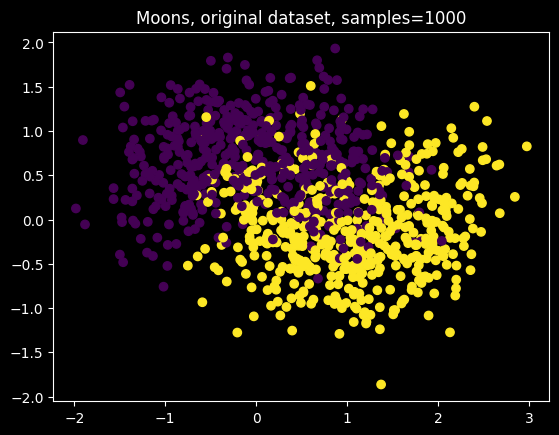

In [102]:
import numpy as np
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1_000, noise=0.4)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Moons, original dataset, samples=" + str(len(X[:, 0])))
plt.show()

split datasets

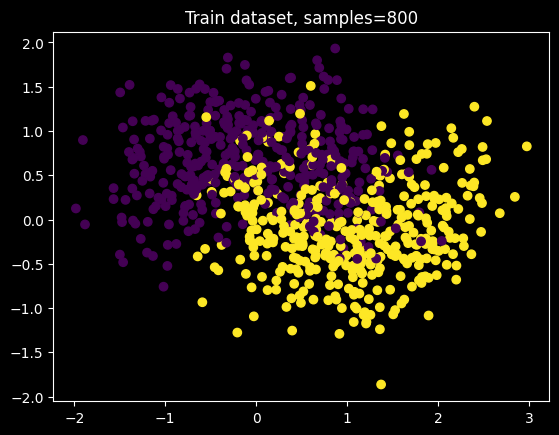

In [103]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2)

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.title("Train dataset, samples=" + str(len(X_train[:, 0])))
plt.show()

Logistic Regression training

In [104]:
from sklearn.linear_model import LogisticRegression

logistic_regression_model = LogisticRegression()
logistic_regression_model.fit(X=X_train, y=y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Support vector machine training

In [105]:
from sklearn import svm

svm_model = svm.SVC()
svm_model.fit(X=X_train, y=y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Random forest classifier training

In [106]:
from sklearn.ensemble import RandomForestClassifier

random_forest_classifier_model = RandomForestClassifier()
random_forest_classifier_model.fit(X=X_train, y=y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

voting classifier training

In [107]:
from sklearn.ensemble import VotingClassifier

voting_classifier_model = VotingClassifier(
    estimators=[
        ('log_reg', logistic_regression_model),
        ('svm', svm_model),
        ('rand_forest', random_forest_classifier_model)],
    voting='hard')

voting_classifier_model = voting_classifier_model.fit(X, y)

auxiliary methods for performance evaluation

In [108]:
from matplotlib.lines import Line2D

def get_accuracy(y_test, y_predictions) -> float :
    assert len(y_test) == len(y_predictions)
    correct: int = 0

    for t, p in zip (y_test, y_predictions):
        if t == p:
            correct += 1

    return correct / len(y_test)


def sub_plot_decision_boundary(model, X_test, y_test):
    x_min, x_max = X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5
    y_min, y_max = X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]

    Z = logistic_regression_model.predict(grid_points)

    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3)

def plot_performance_evaluation(ax, model_name, X_test, y_test, y_predictions):
    accuracy: str = str(get_accuracy(y_test, y_predictions) * 100) + "%"

    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_predictions, marker="o",s=50)
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker=".")
    plt.title(str(model_name) + " | accuracy : " + accuracy)

    legend_elements = [
          Line2D([0], [0], marker='o', color='w', label='Predicted label', markersize=8),
          Line2D([0], [0], marker='.', color='w', label='True label', markersize=8),
    ]
    ax.legend(handles=legend_elements, title="Classification outcomes", loc='lower right')

logistic regression model performance evaluation

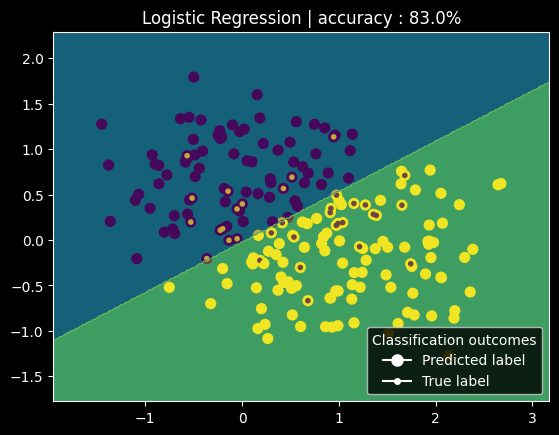

In [109]:
import numpy as np

y_predictions_without_poly = logistic_regression_model.predict(X_test)

fig, ax = plt.subplots()
plt.gca().set_facecolor('teal')

plot_performance_evaluation(ax, model_name="Logistic Regression",X_test=X_test, y_test=y_test, y_predictions=y_predictions_without_poly)
sub_plot_decision_boundary(model=logistic_regression_model, X_test=X_test, y_test=y_test)

plt.show()

support vector machine model performance evaluation

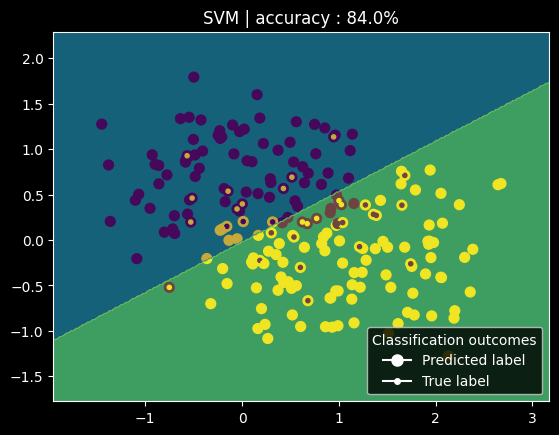

In [110]:
y_predictions_without_poly = svm_model.predict(X_test)

fig, ax = plt.subplots()
plt.gca().set_facecolor('teal')

plot_performance_evaluation(ax, model_name="SVM",X_test=X_test, y_test=y_test, y_predictions=y_predictions_without_poly)
sub_plot_decision_boundary(model=svm_model, X_test=X_test, y_test=y_test)

plt.show()

random forest classifier model performance evaluation

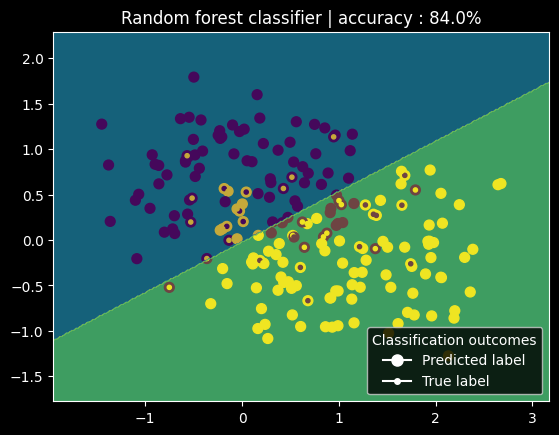

In [111]:
y_predictions_without_poly = random_forest_classifier_model.predict(X_test)

fig, ax = plt.subplots()
plt.gca().set_facecolor('teal')

plot_performance_evaluation(ax, model_name="Random forest classifier",X_test=X_test, y_test=y_test,y_predictions=y_predictions_without_poly)
sub_plot_decision_boundary(random_forest_classifier_model,X_test=X_test,y_test=y_test)
plt.show()

voting classifier performance evaluation

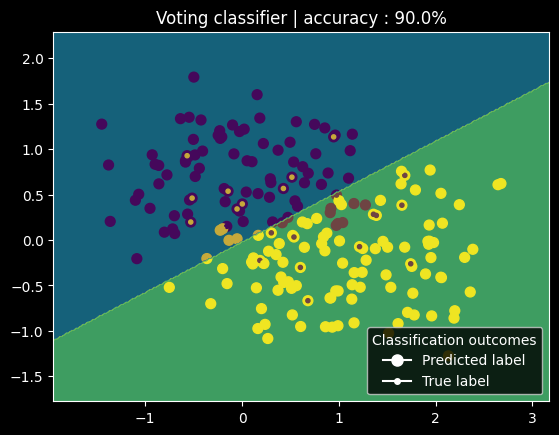

In [112]:
y_predictions_without_poly = voting_classifier_model.predict(X_test)

fig, ax = plt.subplots()
plt.gca().set_facecolor('teal')

plot_performance_evaluation(ax, model_name="Voting classifier",X_test=X_test, y_test=y_test, y_predictions=y_predictions_without_poly)
sub_plot_decision_boundary(model=svm_model, X_test=X_test, y_test=y_test)

plt.show()

Program 2
Import data from any daneXX.txt file (select 2+ datasets to test your work). Each line is a single samples
in a format "input output". Split the dataset into a training and testing sets.
Train a linear parametric model, e.g. LinearRegression().
Train a polynomial parametric model, e.g. PolynomialFeatures().
Compare two models. Verify the models’ performance using r2_score on the testing set.

Grading
- 2 points - Dataset operations
- 3 points - Training and testing the models
5 points total

# Program 2

load data from text files

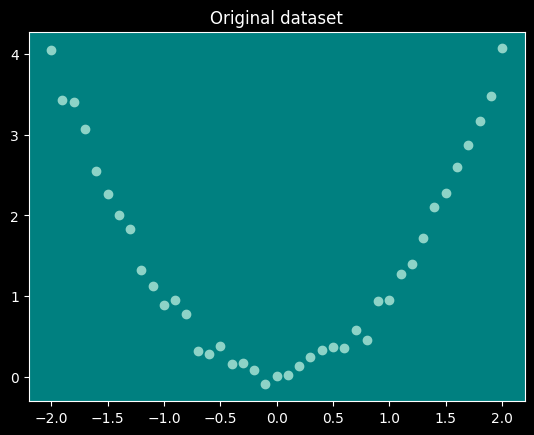

In [113]:
with open("resources/dane1.txt", "r") as data:
    X = []
    y = []
    for line in data:
        X.append(float(line.split(" ")[0]))
        y.append(float(line.split(" ")[1]))

X = np.array(X).reshape(-1, 1)
y = np.array(y)

fig, ax = plt.subplots()
plt.gca().set_facecolor('teal')

plt.scatter(X, y)
plt.title("Original dataset")
plt.show()

split into test and data sets

Train dataset size: 32 | Test dataset size: 9


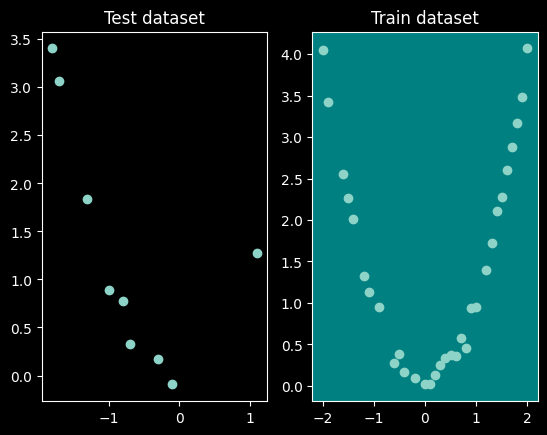

In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

assert len(X) == len(y)
assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)

test_dataset_size = len(X_test)
print(f"Train dataset size: {len(X_train)} | Test dataset size: {len(X_test)}")

fig, (ax1, ax2) = plt.subplots(1,2)
plt.gca().set_facecolor('teal')

ax1.scatter(X_test, y_test)
ax1.set_title("Test dataset")
ax2.scatter(X_train, y_train)
ax2.set_title("Train dataset")

plt.show()

train linear regression model

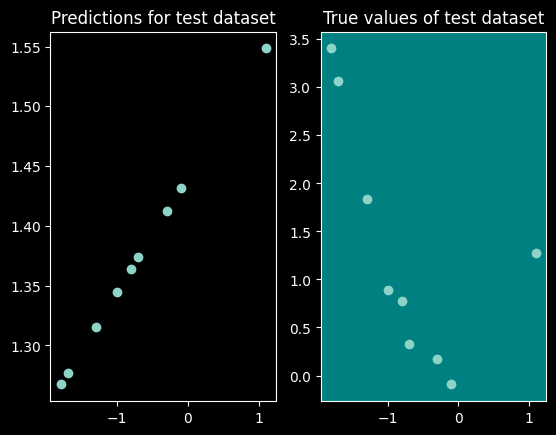

In [115]:
from sklearn.linear_model import LinearRegression

linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train, y_train)


y_predictions_without_poly = linear_regression_model.predict(X_test)

fig, (ax1, ax2) = plt.subplots(1,2)
plt.gca().set_facecolor('teal')
plt.title("Linear regression performance evaluation")

ax1.scatter(X_test, y_predictions_without_poly)
ax1.set_title("Predictions for test dataset")

ax2.scatter(X_test, y_test)
ax2.set_title("True values of test dataset")

plt.show()

train polynomial features model

In [120]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)
X_train_polynomials = poly.fit_transform(X_train)
X_test_polynomials = poly.transform(X_test)

for original_feature, transformed_feature in zip(X_train, X_train_polynomials):
    print(f"original feature: {original_feature}")
    print(f"after poly transformed feature: {transformed_feature}")

linear_regression_polynomial_model = LinearRegression()
linear_regression_polynomial_model.fit(X_train_polynomials, y_train)

original feature: [-0.2]
after poly transformed feature: [ 1.    -0.2    0.04  -0.008]
original feature: [1.]
after poly transformed feature: [1. 1. 1. 1.]
original feature: [-0.6]
after poly transformed feature: [ 1.    -0.6    0.36  -0.216]
original feature: [1.3]
after poly transformed feature: [1.    1.3   1.69  2.197]
original feature: [-1.5]
after poly transformed feature: [ 1.    -1.5    2.25  -3.375]
original feature: [1.2]
after poly transformed feature: [1.    1.2   1.44  1.728]
original feature: [-2.]
after poly transformed feature: [ 1. -2.  4. -8.]
original feature: [-6.383782e-16]
after poly transformed feature: [ 1.00000000e+00 -6.38378200e-16  4.07526726e-31 -2.60156178e-46]
original feature: [0.5]
after poly transformed feature: [1.    0.5   0.25  0.125]
original feature: [0.1]
after poly transformed feature: [1.    0.1   0.01  0.001]
original feature: [-1.6]
after poly transformed feature: [ 1.    -1.6    2.56  -4.096]
original feature: [1.6]
after poly transformed fe

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


evaluate polynomial linear regression model accuracy

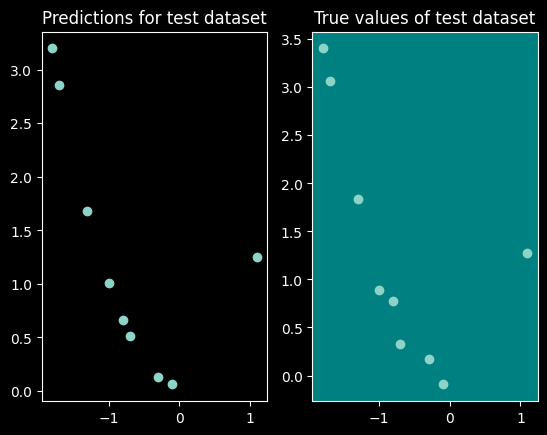

In [125]:
y_predictions_without_poly = linear_regression_polynomial_model.predict(X_test_polynomials)

fig, (ax1, ax2) = plt.subplots(1,2)
plt.gca().set_facecolor('teal')
plt.title("Linear polynomial regression performance evaluation")

ax1.scatter(X_test, y_predictions_without_poly)
ax1.set_title("Predictions for test dataset")

ax2.scatter(X_test, y_test)
ax2.set_title("True values of test dataset")

plt.show()

compare linear regression models with and without polynomial feature enrichment

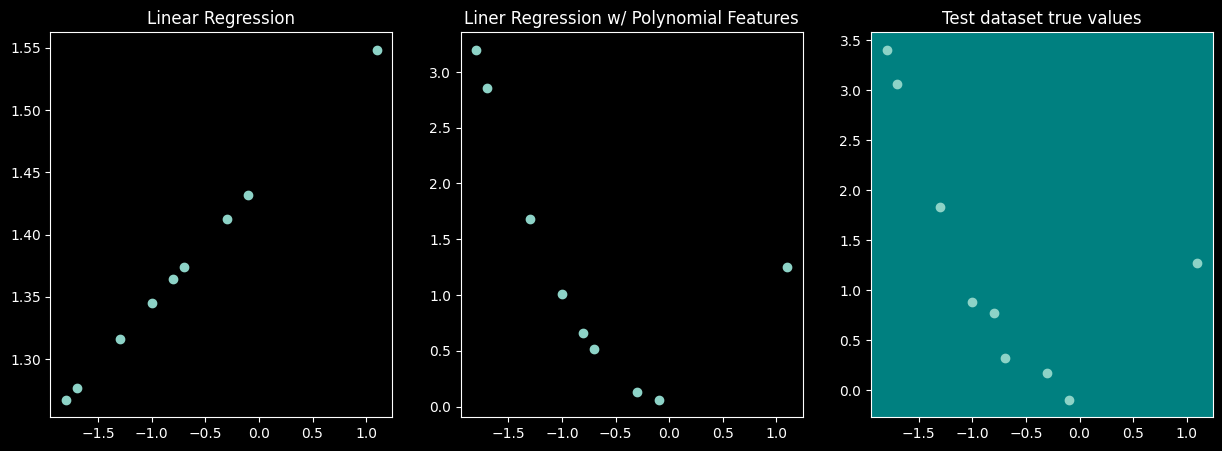

In [147]:
y_predictions_without_poly = linear_regression_model.predict(X_test)
y_predictions_with_poly = linear_regression_polynomial_model.predict(X_test_polynomials)

fig, (ax1, ax2, ax3) = plt.subplots(1,3)
plt.gca().set_facecolor('teal')
plt.title("Compared evaluation")

ax1.scatter(X_test, y_predictions_without_poly)
ax1.set_title("Linear Regression")

ax2.scatter(X_test, y_predictions_with_poly)
ax2.set_title("Liner Regression w/ Polynomial Features")

ax3.scatter(X_test, y_test)
ax3.set_title("Test dataset true values")

fig.set_figwidth(15)
fig.set_figheight(5)

plt.show()

r2_score performance evaluation

In [161]:
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

r2_score_without_poly = r2_score(y_test, y_predictions_without_poly)
r2_score_with_poly = r2_score(y_test, y_predictions_with_poly)

comparison_table = pd.DataFrame(
    {"model": ["Linear Regression", "Linear Regression with Polynomial Feature (3)"], "accuracy measured with R2 score": [r2_score_without_poly, r2_score_with_poly]}
)

print("As can be observed, the R² score of the Linear Regression model with Polynomial Features of degree 3 is very close to 1, which is the maximum possible value of the R² metric. This indicates that the model fits the data very well.")
comparison_table

As can be observed, the R² score of the Linear Regression model with Polynomial Features of degree 3 is very close to 1, which is the maximum possible value of the R² metric. This indicates that the model fits the data very well.


,model,accuracy measured with R2 score
0,Linear Regression,-0.095620
1,Linear Regression with Polynomial Feature (3),0.983963
